In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:

# Load the dataset
df = pd.read_csv("netflix_titles.csv")

In [ ]:
# Select and clean relevant columns
df_ml = df[['type', 'release_year', 'duration', 'rating', 'listed_in']].dropna()


In [ ]:
# Convert duration to numeric values (in minutes or estimated)
def parse_duration(d):
    if 'min' in d:
        return int(d.split()[0])
    elif 'Season' in d:
        return int(d.split()[0]) * 60  # Assume each season ~ 60 mins
    return np.nan

df_ml['duration'] = df_ml['duration'].apply(parse_duration)
df_ml = df_ml.dropna()

In [ ]:

# Encode rating
le_rating = LabelEncoder()
df_ml['rating_encoded'] = le_rating.fit_transform(df_ml['rating'])

In [ ]:

# Vectorize genre (listed_in) with top 10 keywords
vectorizer = CountVectorizer(max_features=10, stop_words='english')
genre_features = vectorizer.fit_transform(df_ml['listed_in']).toarray()

In [ ]:

# Combine features
X = np.hstack((
    df_ml[['release_year', 'duration', 'rating_encoded']].values,
    genre_features
))


In [ ]:

# Encode target
le_type = LabelEncoder()
y = le_type.fit_transform(df_ml['type'])  # 0 = Movie, 1 = TV Show

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

# Train classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le_type.classes_))


Accuracy: 0.9982954545454545

Classification Report:
               precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1216
     TV Show       1.00      1.00      1.00       544

    accuracy                           1.00      1760
   macro avg       1.00      1.00      1.00      1760
weighted avg       1.00      1.00      1.00      1760



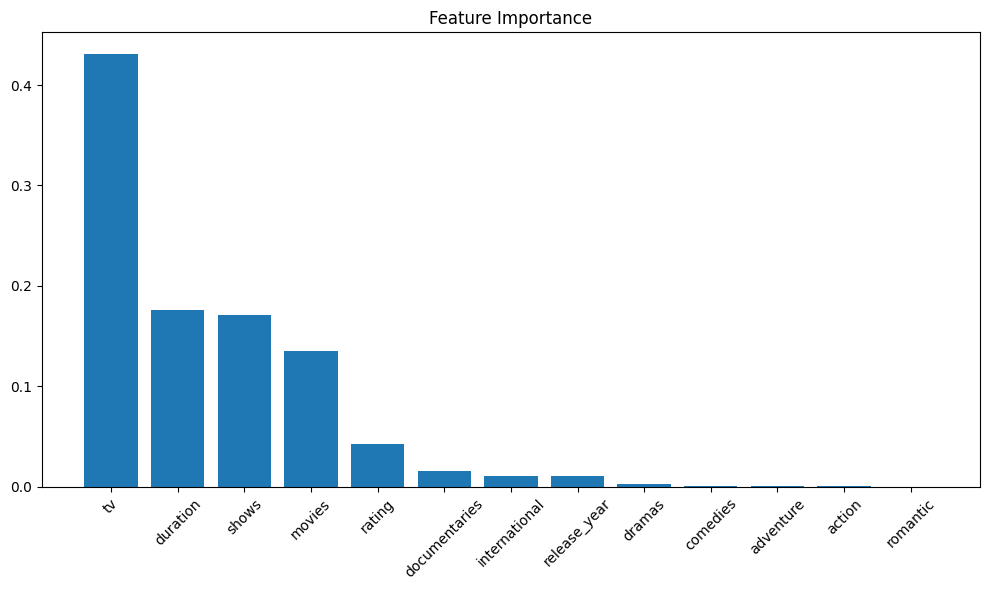

In [ ]:
import matplotlib.pyplot as plt

# Get feature importances from the model
feature_names = ['release_year', 'duration', 'rating'] + vectorizer.get_feature_names_out().tolist()
importances = model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), sorted_features, rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import joblib

# Save the trained model
joblib.dump(model, "netflix_type_classifier.pkl")

# Save encoders and vectorizer
joblib.dump(le_type, "label_encoder_type.pkl")
joblib.dump(le_rating, "label_encoder_rating.pkl")
joblib.dump(vectorizer, "genre_vectorizer.pkl")


['genre_vectorizer.pkl']

In [ ]:
# Prepare a new sample
sample = {
    "release_year": 2022,
    "duration": 120,
    "rating": "TV-14",
    "listed_in": "Dramas, International Movies"
}

# Encode and vectorize
sample_rating = le_rating.transform([sample["rating"]])[0]
sample_genre_vec = vectorizer.transform([sample["listed_in"]]).toarray()  # shape: (1, N)

# Create numerical feature vector and reshape to 2D (1 row, 3 columns)
numeric_features = np.array([[sample["release_year"], sample["duration"], sample_rating]])  # shape: (1, 3)

# Combine numeric and genre features
sample_input = np.hstack((numeric_features, sample_genre_vec))  # shape: (1, 3+N)

# Predict
predicted_type = le_type.inverse_transform(model.predict(sample_input))[0]
print("Predicted type:", predicted_type)


Predicted type: Movie


In [ ]:
# Load dataset again for fresh start
df = pd.read_csv("/content/netflix_titles.csv")

# Drop missing data from essential columns
df_ml = df[['type', 'release_year', 'duration', 'rating', 'listed_in', 'country']].dropna()

# Simplify: use only the first country listed if multiple
df_ml['country'] = df_ml['country'].apply(lambda x: x.split(',')[0].strip())

# Parse 'duration'
def parse_duration(d):
    if 'min' in d:
        return int(d.split()[0])
    elif 'Season' in d:
        return int(d.split()[0]) * 60
    return np.nan

df_ml['duration'] = df_ml['duration'].apply(parse_duration)
df_ml = df_ml.dropna()

# Create binary label for recent/classic
df_ml['is_recent'] = (df_ml['release_year'] > 2015).astype(int)

# Encode 'rating'
le_rating = LabelEncoder()
df_ml['rating_encoded'] = le_rating.fit_transform(df_ml['rating'])

# Vectorize genre
vectorizer = CountVectorizer(max_features=10, stop_words='english')
genre_features = vectorizer.fit_transform(df_ml['listed_in']).toarray()

# Final feature matrix
X = np.hstack((
    df_ml[['release_year', 'duration', 'rating_encoded']].values,
    genre_features
))

# --- Model 1: Predict Country ---
le_country = LabelEncoder()
y_country = le_country.fit_transform(df_ml['country'])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_country, test_size=0.2, random_state=42)
model_country = RandomForestClassifier(n_estimators=100, random_state=42)
model_country.fit(X_train_c, y_train_c)
accuracy_country = model_country.score(X_test_c, y_test_c)

# --- Model 2: Predict Recency ---
y_recent = df_ml['is_recent']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_recent, test_size=0.2, random_state=42)
model_recent = RandomForestClassifier(n_estimators=100, random_state=42)
model_recent.fit(X_train_r, y_train_r)
accuracy_recent = model_recent.score(X_test_r, y_test_r)

accuracy_country, accuracy_recent


(0.5351317440401505, 1.0)

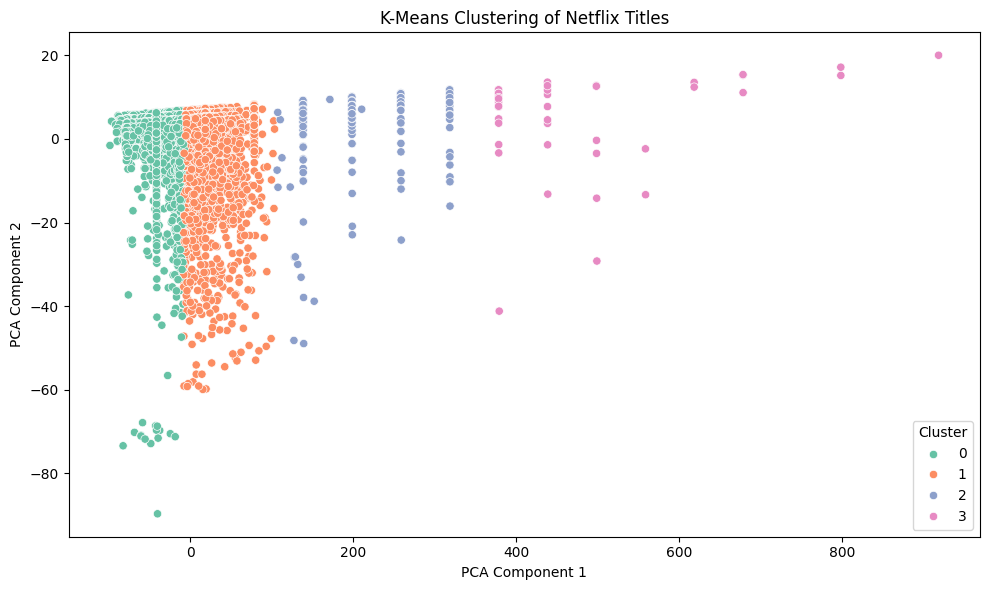

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/netflix_titles.csv")

# Select and clean relevant columns
df_clust = df[['release_year', 'duration', 'rating', 'listed_in']].dropna()

# Convert duration to numeric minutes
def parse_duration(d):
    if 'min' in d:
        return int(d.split()[0])
    elif 'Season' in d:
        return int(d.split()[0]) * 60  # Assume 1 season ≈ 60 mins
    return np.nan

df_clust['duration'] = df_clust['duration'].apply(parse_duration)
df_clust = df_clust.dropna()

# Encode categorical rating
le_rating = LabelEncoder()
df_clust['rating_encoded'] = le_rating.fit_transform(df_clust['rating'])

# Vectorize genres (top 10 words)
vectorizer = CountVectorizer(max_features=10, stop_words='english')
genre_features = vectorizer.fit_transform(df_clust['listed_in']).toarray()

# Combine all features
X = np.hstack((
    df_clust[['release_year', 'duration', 'rating_encoded']].values,
    genre_features
))

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

# Dimensionality reduction for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plotting the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set2')
plt.title("K-Means Clustering of Netflix Titles")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


<ipython-input-3-bc750df43d8a>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='pastel')


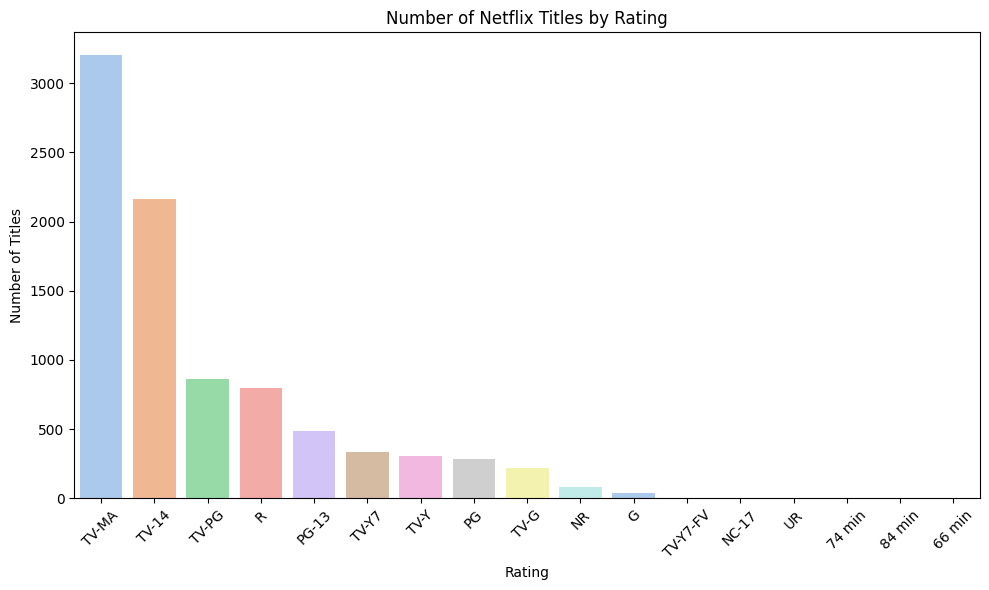

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("netflix_titles.csv")

# Drop missing ratings
df = df.dropna(subset=['rating'])

# Count plot of ratings
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='pastel')
plt.title('Number of Netflix Titles by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


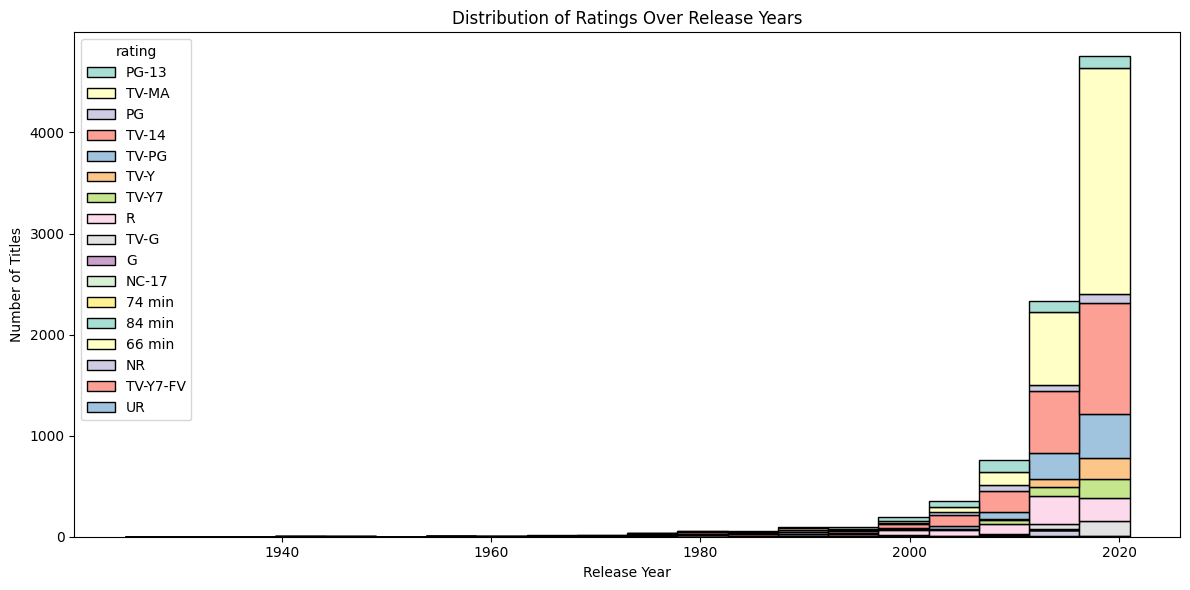

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='release_year', hue='rating', multiple='stack', palette='Set3', bins=20)
plt.title('Distribution of Ratings Over Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()


<ipython-input-5-be136c3ed7ac>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


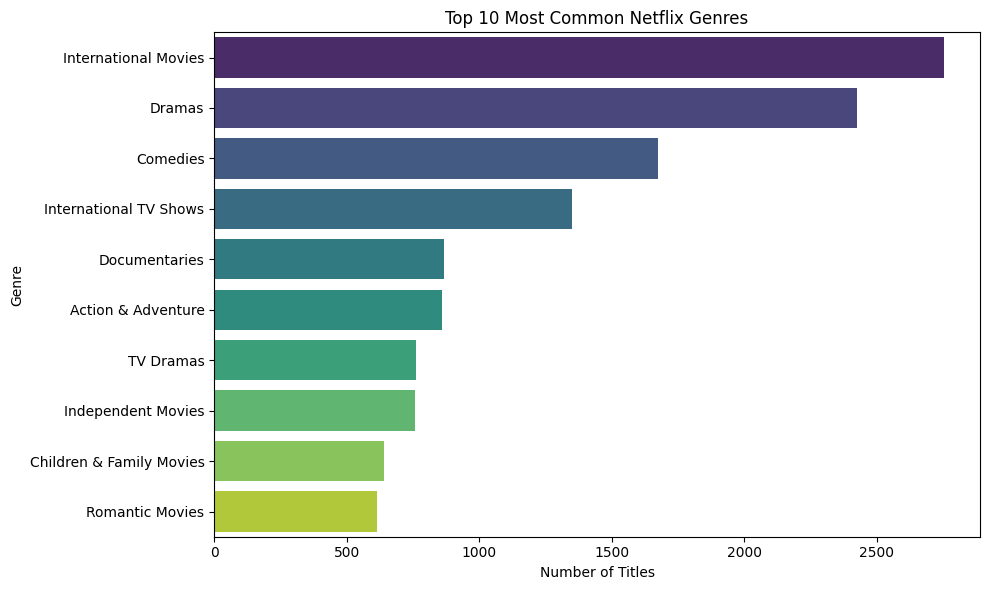

In [5]:
from collections import Counter

# Drop missing genre info
df_genres = df.dropna(subset=['listed_in'])

# Split multiple genres and count
all_genres = df_genres['listed_in'].str.split(', ')
flat_genres = [genre for sublist in all_genres for genre in sublist]
top_genres = pd.Series(Counter(flat_genres)).sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Most Common Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()


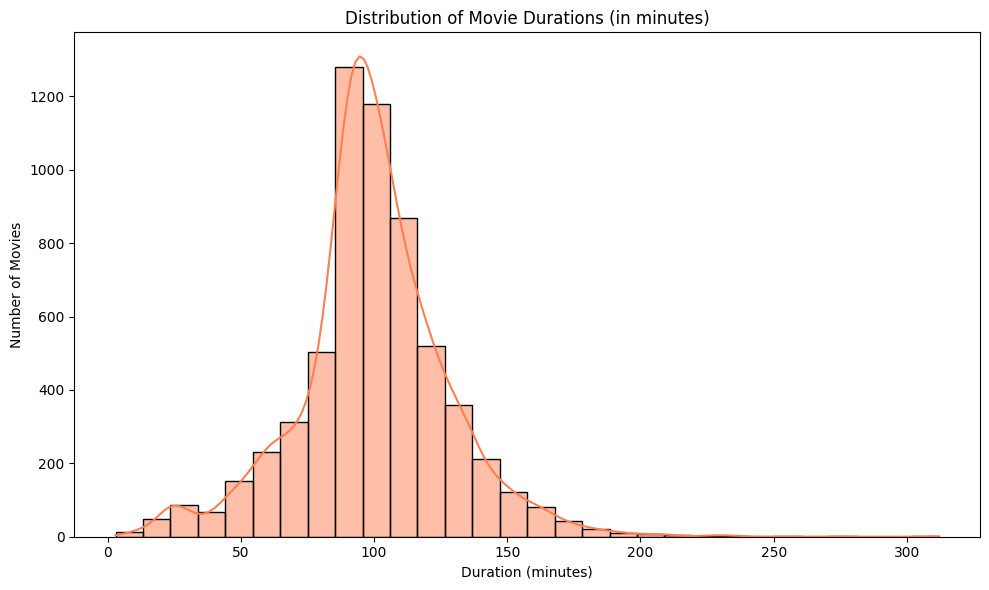

In [7]:
# Filter only movies and parse duration
df_movies = df[df['type'] == 'Movie'].dropna(subset=['duration'])
df_movies['duration_min'] = df_movies['duration'].str.extract('(\d+)').astype(float)

# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_movies['duration_min'], bins=30, color='coral', kde=True)
plt.title('Distribution of Movie Durations (in minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()


<ipython-input-8-d718c04fe58f>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')


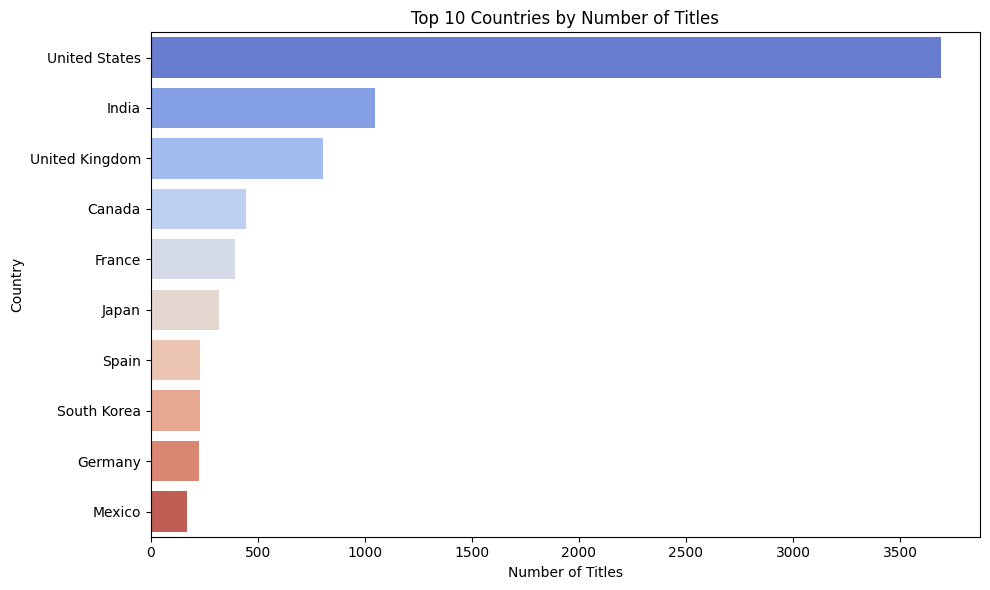

In [8]:
# Split and count countries
df_country = df.dropna(subset=['country'])
all_countries = df_country['country'].str.split(', ')
flat_countries = [country for sublist in all_countries for country in sublist]
top_countries = pd.Series(Counter(flat_countries)).sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


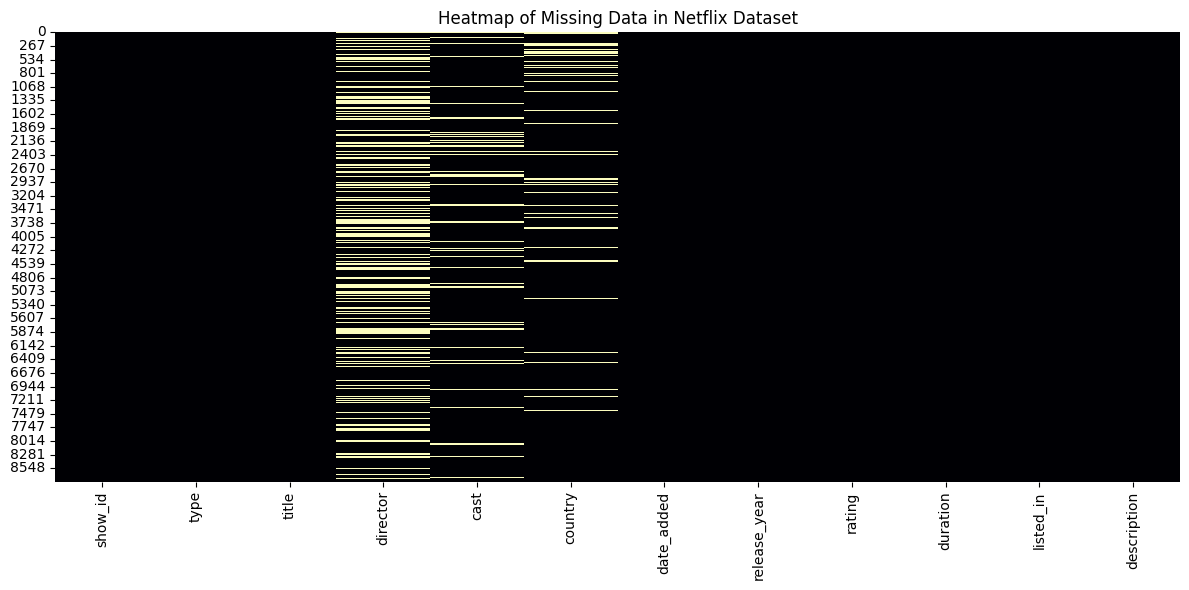

In [9]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='magma')
plt.title('Heatmap of Missing Data in Netflix Dataset')
plt.tight_layout()
plt.show()


<ipython-input-10-4d9d700f335c>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rating, x='rating', order=df_rating['rating'].value_counts().index, palette='pastel', ax=axs[0, 0])
<ipython-input-10-4d9d700f335c>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm', ax=axs[0, 1])
<ipython-input-10-4d9d700f335c>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis', ax=axs[2, 0])
/usr/local/lib/python3.11/dist-packa

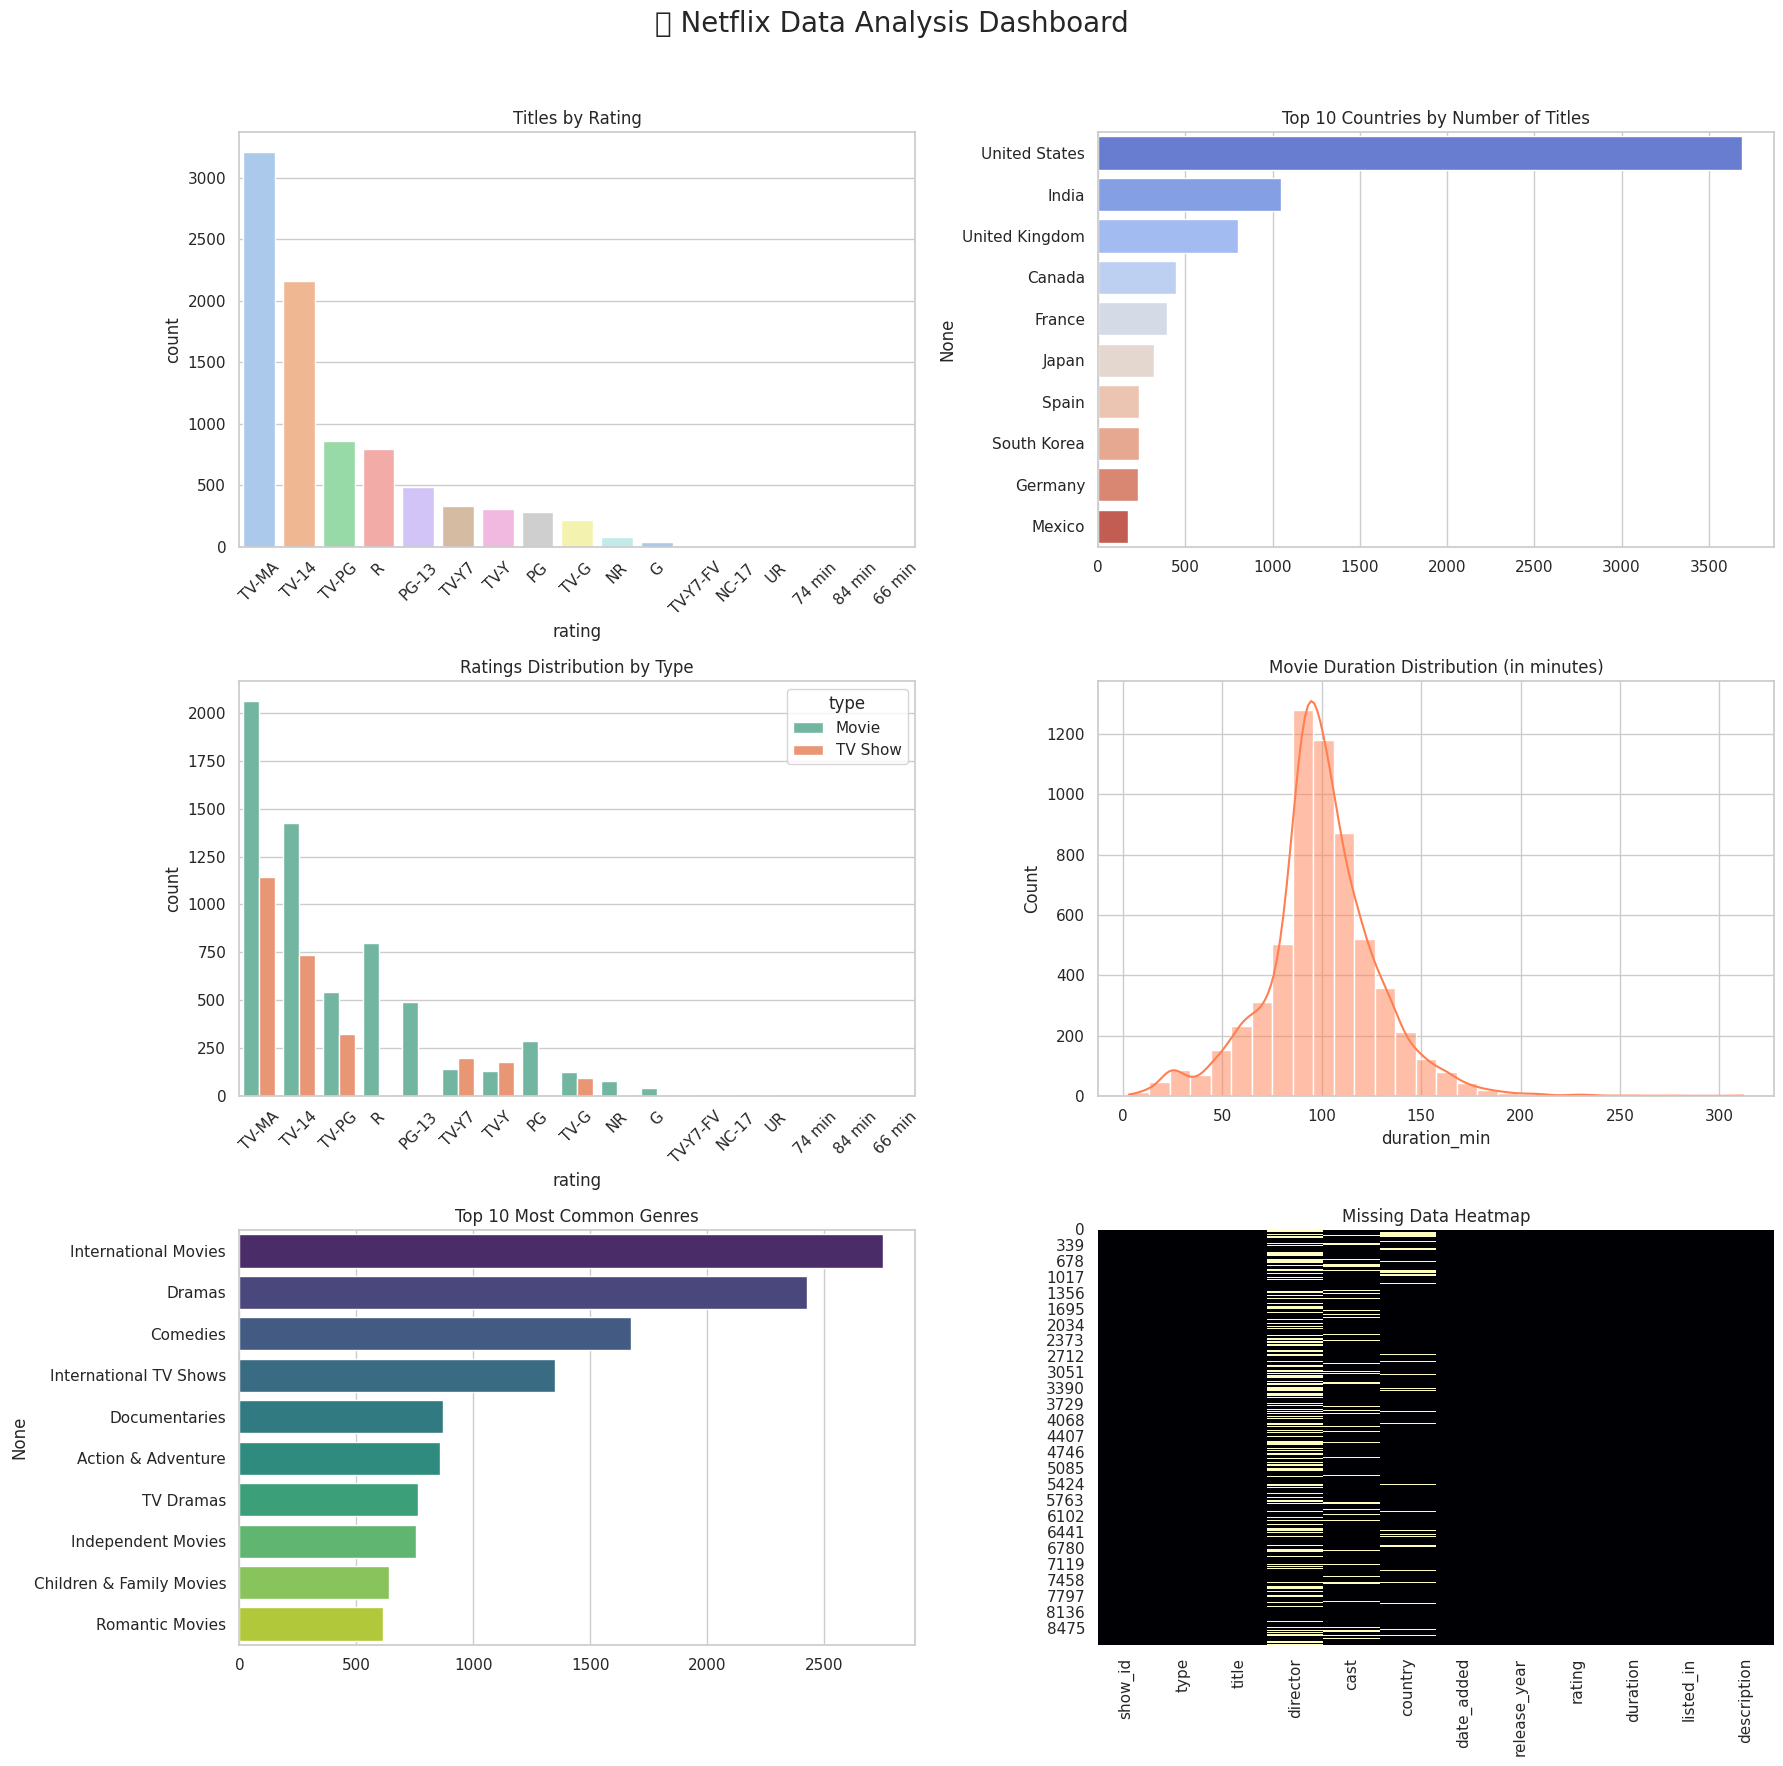

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load dataset
df = pd.read_csv("netflix_titles.csv")

# Set style
sns.set(style="whitegrid")

# Create subplot layout
fig, axs = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle("📊 Netflix Data Analysis Dashboard", fontsize=20)

# --- Plot 1: Title count by Rating
df_rating = df.dropna(subset=['rating'])
sns.countplot(data=df_rating, x='rating', order=df_rating['rating'].value_counts().index, palette='pastel', ax=axs[0, 0])
axs[0, 0].set_title("Titles by Rating")
axs[0, 0].tick_params(axis='x', rotation=45)

# --- Plot 2: Top 10 Countries by Titles
df_country = df.dropna(subset=['country'])
flat_countries = [c for sublist in df_country['country'].str.split(', ') for c in sublist]
top_countries = pd.Series(Counter(flat_countries)).sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm', ax=axs[0, 1])
axs[0, 1].set_title("Top 10 Countries by Number of Titles")

# --- Plot 3: Ratings by Type
sns.countplot(data=df, x='rating', hue='type', order=df['rating'].value_counts().index, palette='Set2', ax=axs[1, 0])
axs[1, 0].set_title("Ratings Distribution by Type")
axs[1, 0].tick_params(axis='x', rotation=45)

# --- Plot 4: Movie Duration Distribution
df_movies = df[df['type'] == 'Movie'].dropna(subset=['duration'])
df_movies['duration_min'] = df_movies['duration'].str.extract('(\d+)').astype(float)
sns.histplot(df_movies['duration_min'], bins=30, kde=True, color='coral', ax=axs[1, 1])
axs[1, 1].set_title("Movie Duration Distribution (in minutes)")

# --- Plot 5: Top 10 Genres
df_genres = df.dropna(subset=['listed_in'])
flat_genres = [g for sublist in df_genres['listed_in'].str.split(', ') for g in sublist]
top_genres = pd.Series(Counter(flat_genres)).sort_values(ascending=False).head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis', ax=axs[2, 0])
axs[2, 0].set_title("Top 10 Most Common Genres")

# --- Plot 6: Missing Data Heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='magma', ax=axs[2, 1])
axs[2, 1].set_title("Missing Data Heatmap")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
